# Install Dependencies and Import

In [2]:
!pip install -q --upgrade numerapi numerai-tools

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
import pickle

from datetime import timedelta
import time

from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution, neutralize


import warnings
warnings.filterwarnings('ignore')

# Inline plots
%matplotlib inline

# Loading Numerai datasets  
  
Выкатили новую версию данных `v5.1`.

In [4]:
# Инициация NumerAPI
napi = NumerAPI()

all_datasets = napi.list_datasets()
dataset_versions = list(set(d.split('/')[0] for d in all_datasets))

DATA_VERSION = max(dataset_versions)

print("LIST AVAILABLE VERSIONS:\n", dataset_versions)
print('--------------------')
print('')
print('ALL FILES:')
print('--------------------')

[file for file in all_datasets if file.startswith(DATA_VERSION)]

LIST AVAILABLE VERSIONS:
 ['v5.0', 'v5.1']
--------------------

ALL FILES:
--------------------


['v5.1/features.json',
 'v5.1/live.parquet',
 'v5.1/live_benchmark_models.parquet',
 'v5.1/live_example_preds.csv',
 'v5.1/live_example_preds.parquet',
 'v5.1/meta_model.parquet',
 'v5.1/train.parquet',
 'v5.1/train_benchmark_models.parquet',
 'v5.1/validation.parquet',
 'v5.1/validation_benchmark_models.parquet',
 'v5.1/validation_example_preds.csv',
 'v5.1/validation_example_preds.parquet']

Пока поднадобятся 4 датасета. Загружаю в среду Google Colab.

In [6]:
napi.download_dataset(f"{DATA_VERSION}/features.json")
napi.download_dataset(f"{DATA_VERSION}/train.parquet")
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")
napi.download_dataset(f"{DATA_VERSION}/meta_model.parquet")

v5.1/features.json: 307kB [00:00, 2.46MB/s]                           
v5.1/train.parquet: 2.47GB [00:46, 53.0MB/s]                            
v5.1/validation.parquet: 3.80GB [01:13, 51.7MB/s]                            
v5.1/meta_model.parquet: 9.05MB [00:00, 23.7MB/s]                            


'v5.1/meta_model.parquet'

# Feature Metadata  
  
В версии `v5.1` 18 наборов признаков и 37 таргетов.  
- К таргетам вернусь на стадии создания ансамбля.  

**Feature Sets:**
- Общие наборы: `small`, `medium`, `all`. Включают в себя признаки из разных наборов.
- `v2_equivalent_features` и `v3_equivalent_features` - для совместимости со старыми версиями данных. Но признаки из этих наборов есть и в тематических.  
- `fncv3_features` - специальный набор фичей, созданный для `feature neutral correlation version 3`.
- Тематические наборы: `intelligence`, `charisma`, `strength`, `dexterity`, `constitution`, `wisdom`, `agility`, `serenity`, `sunshine`, `rain`, `midnight`, `faith`.  

In [7]:
# Загрузка метаданных признаков
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

groups_dict = {}
for general_set in ['small', 'medium', 'all']:
        groups_dict[general_set] = {}
        for k, v in feature_sets.items():
                if k not in ['small', 'medium']:
                    groups_dict[general_set][k] = list(set(feature_sets[general_set]) & set(feature_sets[k]))

df = pd.DataFrame(groups_dict)
df = df.applymap(lambda x: len(x)).sort_values(by='all', ascending=False)
df

,small,medium,all
all,42,740,2562
v3_equivalent_features,15,400,1000
rain,20,0,666
fncv3_features,8,400,400
constitution,2,134,335
sunshine,5,130,325
v2_equivalent_features,7,304,304
charisma,3,116,290
midnight,0,122,244
faith,0,35,186


Выбираю оптимальный набор - `medium` (740 признаков).  

Сохраняю словарь `medium_dict` для нейтрализации признаков.

In [8]:
medium_dict = groups_dict['medium']
medium_features = medium_dict['all']

# Uploading Datasets

In [13]:
# Общая информация о датафрейме
def describe_df(df: pd.DataFrame):

    n_rows, n_cols = df.shape
    missing_total = df.isnull().sum().sum()
    min_era = df['era'].min()
    max_era = df['era'].max()
    total_eras = df['era'].nunique()

    print(f"Размер: {n_rows} × {n_cols}")
    print(f"Пропуски: {missing_total}")
    print(f"Эры: {min_era}-{max_era} ({total_eras})")

## Train


In [14]:
# Load dataset with medium features
train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era", "target"] + medium_features)
train['era'] = train['era'].astype(int)

describe_df(train)
train.head(3)

Размер: 2746270 × 742
Пропуски: 0
Эры: 1-574 (574)


,era,target,feature_tumbling_insurrectional_schematisation,feature_winteriest_falconine_isodimorphism,feature_typic_geegaw_internationale,feature_informed_eminent_chaplain,feature_brummagem_freckliest_papaverine,feature_estranging_stylish_liker,feature_quartered_quadricipital_stirrup,feature_phototactic_dire_ethnarchy,...,feature_antidepressant_rationalistic_adaptation,feature_unspiritual_hypothetical_freetown,feature_semestrial_coarser_viscera,feature_evacuated_portliest_exterritoriality,feature_unblocked_converging_zollverein,feature_veriest_petrifying_synergy,feature_whatsoever_muskier_dangler,feature_tribunicial_waur_conway,feature_dumpy_funkiest_homestead,feature_orchitic_unstigmatized_fyrd
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,1,0.25,2,2,3,2,0,2,2,2,...,4,1,2,2,1,2,3,1,0,3
n003bba8a98662e4,1,0.25,2,2,4,2,0,2,2,4,...,2,3,2,2,0,1,0,0,0,0
n003bee128c2fcfc,1,0.75,2,2,0,2,2,2,2,1,...,2,0,2,2,1,3,1,3,3,1


### Target  
  
`Target` (float32) распределён по 5 неравным бинам: 0, 0.25, 0.5, 0.75, 1.0  
Это распределение относится как ко всему датасету, так и для каждой эры отдельно.



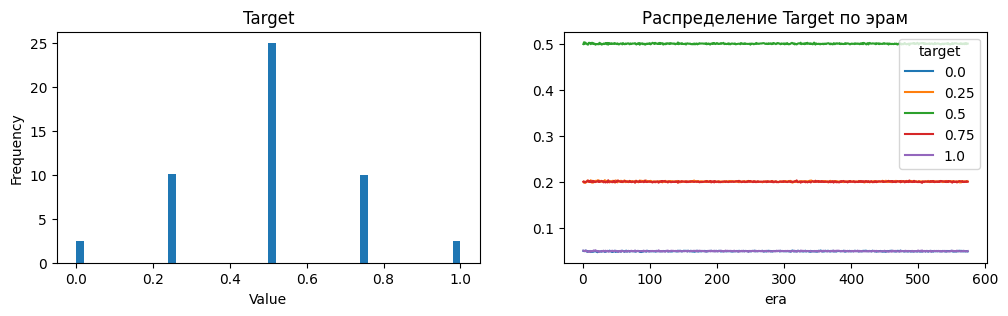

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

train["target"].plot(kind="hist", title="Target", xlabel="Value", density=True, bins=50, ax=ax1)
train.groupby('era')['target'].value_counts(normalize=True).unstack(fill_value=0).plot(ax=ax2)

ax2.set_title("Распределение Target по эрам")
plt.show()

### Analysis of Missing Values

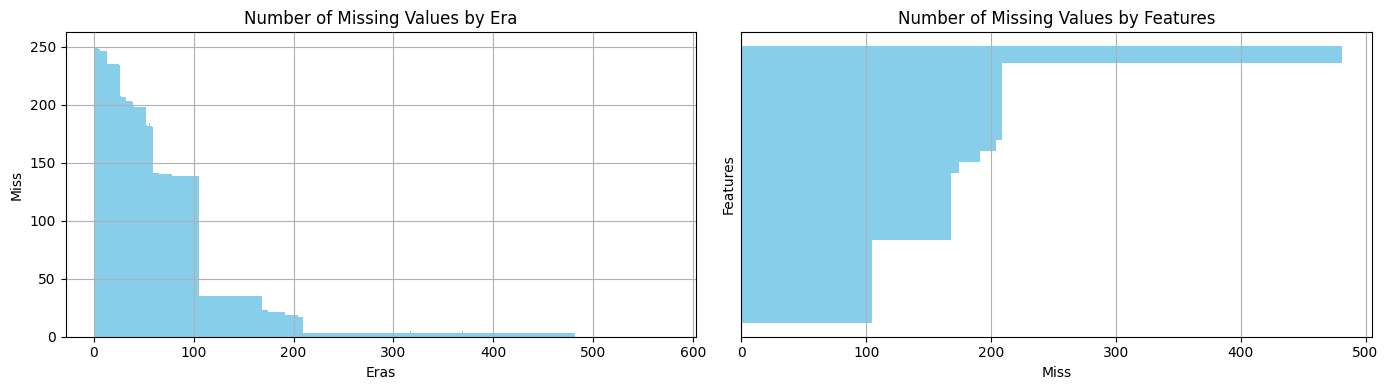

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Пропуски по эрам
missing_eras = train.groupby('era')[medium_features].apply(lambda x: (x == 2).all(axis=0))
missing_eras = missing_eras.reset_index()
missing_eras['miss_count'] = missing_eras[medium_features].sum(axis=1)

axes[0].bar(missing_eras['era'], missing_eras['miss_count'], color='skyblue', width=1)
axes[0].set_title("Number of Missing Values by Era")
axes[0].set_xlabel("Eras")
axes[0].set_ylabel("Miss")
axes[0].grid()


# Пропуски по признакам
missing_features = missing_eras[medium_features].sum(axis=0)
missing_features = pd.DataFrame(missing_features).rename(columns={0: 'miss_count'})
missing_features["%"] = missing_features.apply(lambda x: x / len(medium_features) * 100)
top_missing_features = missing_features.sort_values('miss_count', ascending=False)[:50]

axes[1].barh(top_missing_features.index, top_missing_features['miss_count'], color='skyblue', height=1)
axes[1].set_title("Number of Missing Values by Features")
axes[1].set_xlabel("Miss")
axes[1].set_ylabel("Features")
axes[1].set_yticks([])
axes[1].invert_yaxis()
axes[1].grid()


plt.tight_layout()
plt.show()

3 признака с большим количеством пропусков нужно удалить из всех наборов.

In [17]:
excluded_features = set(missing_features[missing_features['%'] > 50].index)

dict_medium_clean = {key: set(value) - excluded_features for key, value in medium_dict.items()}
medium_features_clean = list(dict_medium_clean['all'])


print(f"Осталось признаков {len(dict_medium_clean['all'])} из {len(medium_features)}")
print(f"Удалённые признаки: {excluded_features})")
missing_features.sort_values('%', ascending=False).head(5)

Осталось признаков 737 из 740
Удалённые признаки: {'feature_incarnate_hardened_annelida', 'feature_machinable_tepidity_ordnance', 'feature_unregistered_veiniest_hooliganism'})


,miss_count,%
feature_unregistered_veiniest_hooliganism,481,65.000000
feature_machinable_tepidity_ordnance,481,65.000000
feature_incarnate_hardened_annelida,481,65.000000
feature_creeping_dorty_frenchification,209,28.243243
feature_septuple_wale_chokey,209,28.243243


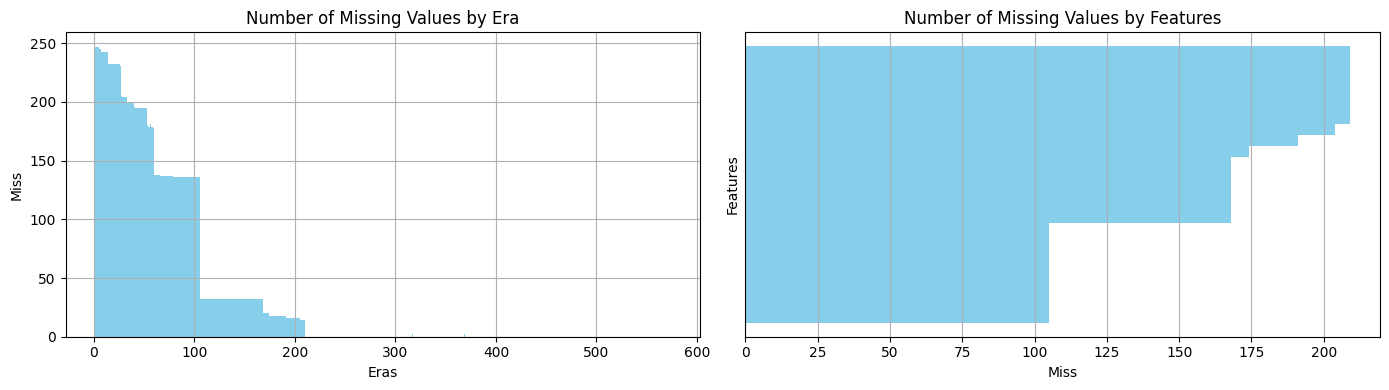

In [19]:
# Проверка после удаления признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


# Пропуски по эрам
missing_eras = train.groupby('era')[medium_features_clean].apply(lambda x: (x == 2).all(axis=0))
missing_eras = missing_eras.reset_index()
missing_eras['miss_count'] = missing_eras[medium_features_clean].sum(axis=1)

axes[0].bar(missing_eras['era'], missing_eras['miss_count'], color='skyblue', width=1)
axes[0].set_title("Number of Missing Values by Era")
axes[0].set_xlabel("Eras")
axes[0].set_ylabel("Miss")
axes[0].grid()


# Пропуски по признакам
missing_features = missing_eras[medium_features_clean].sum(axis=0)
missing_features = pd.DataFrame(missing_features).rename(columns={0: 'miss_count'})
missing_features["%"] = missing_features.apply(lambda x: x / len(medium_features_clean) * 100)
top_missing_features = missing_features.sort_values('miss_count', ascending=False)[:50]

axes[1].barh(top_missing_features.index, top_missing_features['miss_count'], color='skyblue', height=1)
axes[1].set_title("Number of Missing Values by Features")
axes[1].set_xlabel("Miss")
axes[1].set_ylabel("Features")
axes[1].set_yticks([])
axes[1].invert_yaxis()
axes[1].grid()


plt.tight_layout()
plt.show()

Начиная с эры 210 почти нет пропусков.  
Обрезаю Train c `first_clean_era`.  

In [22]:
first_clean_era = missing_eras[missing_eras['miss_count'] == 0]['era'].min()

train_clean = train[train.era >= first_clean_era][['era', 'target'] + medium_features_clean]

print(f"Строки: {train_clean.shape[0]}")
print(f"Столбцы: {train_clean.shape[1]}")
print(f"Признаки: {len(medium_features_clean)}")
print(f"Эры: {train_clean['era'].min()}-{train_clean['era'].max()} ({train_clean['era'].nunique()})")

Строки: 1865208
Столбцы: 739
Признаки: 737
Эры: 210-574 (365)


## Validation

In [20]:
# Load dataset
validation = pd.read_parquet(f"{DATA_VERSION}/validation.parquet", columns=["era", "target", "data_type"] + medium_features_clean)
validation['era'] = validation['era'].astype(int)

validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

describe_df(validation)
validation.head(3)

Размер: 3821032 × 739
Пропуски: 0
Эры: 575-1190 (616)


,era,target,feature_tumbling_insurrectional_schematisation,feature_winteriest_falconine_isodimorphism,feature_typic_geegaw_internationale,feature_informed_eminent_chaplain,feature_brummagem_freckliest_papaverine,feature_estranging_stylish_liker,feature_quartered_quadricipital_stirrup,feature_phototactic_dire_ethnarchy,...,feature_antidepressant_rationalistic_adaptation,feature_unspiritual_hypothetical_freetown,feature_semestrial_coarser_viscera,feature_evacuated_portliest_exterritoriality,feature_unblocked_converging_zollverein,feature_veriest_petrifying_synergy,feature_whatsoever_muskier_dangler,feature_tribunicial_waur_conway,feature_dumpy_funkiest_homestead,feature_orchitic_unstigmatized_fyrd
id,,,,,,,,,,,,,,,,,,,,,
n000101811a8a843,575,0.75,4,1,4,1,1,1,1,4,...,4,1,0,4,0,3,4,3,1,4
n001e1318d5072ac,575,0.00,3,1,1,1,3,3,0,2,...,0,3,3,3,2,3,4,3,4,2
n002a9c5ab785cbb,575,0.50,3,2,0,1,1,3,1,3,...,1,1,1,3,4,1,0,1,2,4


In [23]:
# Embargo the first 4 eras
last_era = int(train_clean["era"].unique()[-1])
eras_embargo = [era for era in [last_era + i for i in range(1, 5)]]
validation = validation[~validation["era"].isin(eras_embargo)]

print(f'Train eras: {train_clean.era.min()}-{train_clean.era.max()} ({train_clean["era"].nunique()})')
print(f'Validation eras: {validation.era.min()}-{validation.era.max()} ({validation["era"].nunique()})')
print(f'Eras embargo: {eras_embargo}')

Train eras: 210-574 (365)
Validation eras: 579-1190 (612)
Eras embargo: [575, 576, 577, 578]


### Meta Model  

Добавлю к `validation` столбец `numerai_meta_model` для рассчёта `MMC`.
   
- `MMC (Meta Model Contribution)` — мера того, насколько уникально и добавочно модель улучшает `Numerai Meta Model`.

In [24]:
meta_model = pd.read_parquet(f"{DATA_VERSION}/meta_model.parquet")
meta_model['era'] = meta_model['era'].astype(int)

describe_df(meta_model)
meta_model.head(3)

Размер: 374710 × 3
Пропуски: 0
Эры: 1133-1190 (58)


,era,data_type,numerai_meta_model
id,,,
n0001a161ef7f066,1133,validation,0.598030
n000683e569f9b8b,1133,validation,0.760381
n000df72d86f2b54,1133,validation,0.851571


In [25]:
# Join numerai_meta_model and validation
validation = validation.join(meta_model["numerai_meta_model"], how="left")
validation.rename(columns={"numerai_meta_model": "meta_model"}, inplace=True)

# Сколько строк в каждом датафрейме
print(f"Строк в validation: {len(validation)}")
print(f"Строк в meta_model: {len(meta_model)}")

# Совпадающие id (индексы)
common_ids = validation.index.intersection(meta_model.index)
print(f"Совпадающих id: {len(common_ids)}")

Строк в validation: 3798341
Строк в meta_model: 374710
Совпадающих id: 374710


<Axes: title={'center': 'Number of rows per era'}, xlabel='Era'>

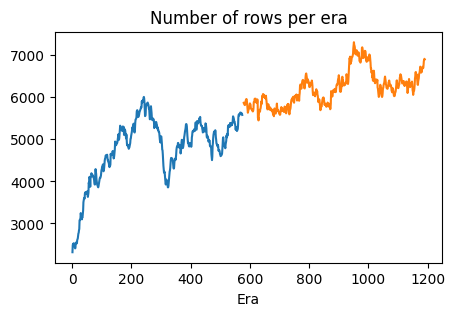

In [26]:
# Распределение по эрам (строк на эру)
train.groupby("era").size().plot(
    title="Number of rows per era",
    figsize=(5, 3),
    xlabel="Era")

validation.groupby("era").size().plot(
    title="Number of rows per era",
    figsize=(5, 3),
    xlabel="Era")

# Saving Data  

- `train_medium.parquet` - Train без пропусков с 210 по 574 эры. Всего - 365 эр.
- `validation_medium.parquet` - Validation с 579 по 1190 эры и эмбарго 4 эры (575-578). Всего - 612 эр. Добавлен столбец `numerai_meta_model` с 1133 по 1190 эры.
- `dict_medium_clean.pkl` - Словарь для Medium, сгруппированный по наборам для нейтрализаии.

In [28]:
train_clean.to_parquet("/content/drive/MyDrive/Colab Notebooks/train_medium.parquet")
validation.to_parquet("/content/drive/MyDrive/Colab Notebooks/validation_medium.parquet")

with open("/content/drive/MyDrive/Colab Notebooks/dict_medium_clean.pkl", "wb") as f:
    pickle.dump(dict_medium_clean, f)